## Phase 2 – Exploratory Data Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

np.random.seed(42)

# Project root relative paths
DATA_PATH = Path("../data_processed/gold_100k.csv")
FIG_DIR = Path("../reports/eda/figures")
TAB_DIR = Path("../reports/eda/tables")

# Creating the folders
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


# 1. Load +  Dataset anatomy

In [3]:
# --- Load data ---
df = pd.read_csv(DATA_PATH)

print("Loaded:", DATA_PATH)
print("Shape (rows, cols):", df.shape)
print("Columns:", list(df.columns))

# --- Core counts ---
n_rows = len(df)
n_users = df["user_id"].nunique()
n_streams = df["stream_id"].nunique()
n_streamers = df["streamer_name"].nunique()

# --- Time coverage ---
t_start_min = int(df["start_time"].min())
t_start_max = int(df["start_time"].max())
t_stop_min  = int(df["stop_time"].min())
t_stop_max  = int(df["stop_time"].max())

# --- Duration sanity ---
dur_min = float(df["duration_minutes"].min())
dur_med = float(df["duration_minutes"].median())
dur_mean = float(df["duration_minutes"].mean())
dur_p95 = float(df["duration_minutes"].quantile(0.95))

anatomy = pd.DataFrame({
    "metric": [
        "n_rows",
        "n_users",
        "n_streams",
        "n_streamers",
        "start_time_min",
        "start_time_max",
        "stop_time_min",
        "stop_time_max",
        "duration_minutes_min",
        "duration_minutes_median",
        "duration_minutes_mean",
        "duration_minutes_p95",
    ],
    "value": [
        n_rows,
        n_users,
        n_streams,
        n_streamers,
        t_start_min,
        t_start_max,
        t_stop_min,
        t_stop_max,
        round(dur_min, 2),
        round(dur_med, 2),
        round(dur_mean, 2),
        round(dur_p95, 2),
    ]
})

display(anatomy)

# Save for thesis writing
anatomy.to_csv(TAB_DIR / "eda_anatomy_summary.csv", index=False)
print("Saved table to:", (TAB_DIR / "eda_anatomy_summary.csv").as_posix())

Loaded: ../data_processed/gold_100k.csv
Shape (rows, cols): (3051733, 7)
Columns: ['user_id', 'stream_id', 'streamer_name', 'start_time', 'stop_time', 'duration_intervals', 'duration_minutes']


,metric,value
0,n_rows,3051733.00
1,n_users,100000.00
2,n_streams,739991.00
3,n_streamers,162625.00
4,start_time_min,0.00
5,start_time_max,6147.00
6,stop_time_min,1.00
7,stop_time_max,6148.00
8,duration_minutes_min,10.00
9,duration_minutes_median,10.00


Saved table to: ../reports/eda/tables/eda_anatomy_summary.csv


# 2. Activity over time

Number of unique start timesteps: 6148
Min timestep: 0
Max timestep: 6147


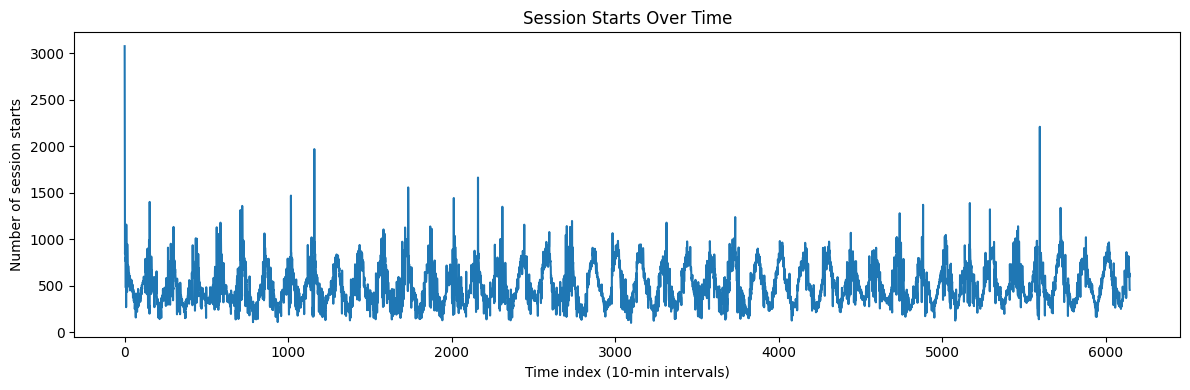

In [4]:
# Count session starts per timestep
starts_per_t = df.groupby("start_time").size()

print("Number of unique start timesteps:", starts_per_t.shape[0])
print("Min timestep:", starts_per_t.index.min())
print("Max timestep:", starts_per_t.index.max())

# Plot raw activity
plt.figure(figsize=(12,4))
plt.plot(starts_per_t.index, starts_per_t.values)
plt.xlabel("Time index (10-min intervals)")
plt.ylabel("Number of session starts")
plt.title("Session Starts Over Time")
plt.tight_layout()
plt.savefig(FIG_DIR / "session_starts_over_time_raw.png", dpi=200)
plt.show()

### Temporal Distribution of Session Starts

The raw activity plot reveals a strong periodic pattern with a cycle of approximately 144 timesteps, which corresponds to roughly one day given the 10-minute snapshot interval.

This indicates that user activity follows a clear daily rhythm. However, since the dataset does not include explicit timezone information, it is not possible to determine whether the peaks correspond to daytime or nighttime activity.

Overall, the activity level remains relatively stable throughout the 43-day observation window. No substantial long-term upward or downward trend is observed, suggesting that the dataset does not exhibit strong temporal distribution shifts.

Occasional spikes in session starts are visible, likely corresponding to highly popular streams or platform-wide events. However, these spikes are relatively rare and do not dominate the overall activity pattern.

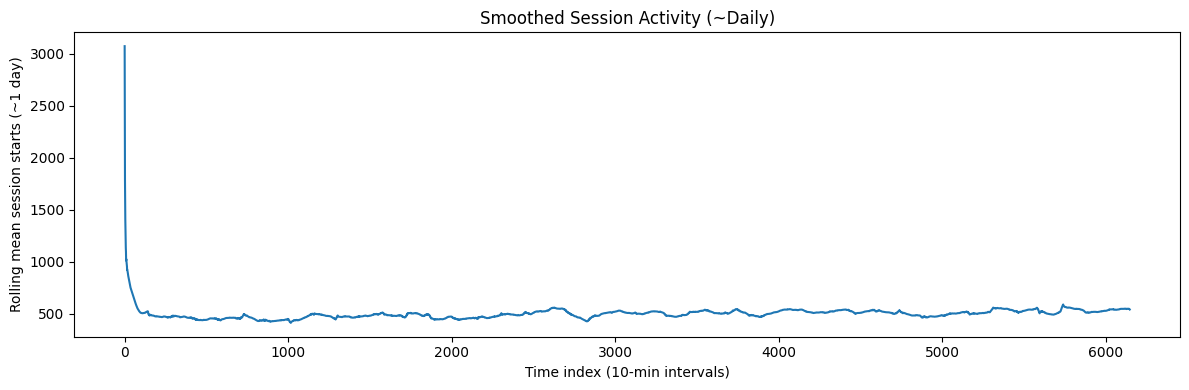

In [5]:
rolling = starts_per_t.rolling(window=144, min_periods=1).mean()

plt.figure(figsize=(12,4))
plt.plot(rolling.index, rolling.values)
plt.xlabel("Time index (10-min intervals)")
plt.ylabel("Rolling mean session starts (~1 day)")
plt.title("Smoothed Session Activity (~Daily)")
plt.tight_layout()
plt.savefig(FIG_DIR / "session_starts_over_time_smoothed.png", dpi=200)
plt.show()

### Smoothed Activity Trend (Daily Rolling Mean)

To better observe long-term activity patterns, a rolling mean with a window size of 144 timesteps (approximately one day) was applied.

The smoothed curve indicates that the average session start activity remains within a relatively narrow range throughout the dataset. This suggests that the dataset maintains a stable level of engagement over time.

Overall, the smoothed trend confirms that the temporal distribution of user activity is relatively stable across the observation period, which supports the use of a temporal train–test split in subsequent modeling stages.

A large spike is observed at the very beginning of the series in both the raw and smoothed plots.

This phenomenon is likely caused by the snapshot-based nature of the dataset. Since the first snapshot captures all users who were already watching streams at the start of the observation period, these sessions appear as if they started at the same timestep.

Consequently, the first few timesteps may contain artificially inflated session start counts and should be interpreted with caution.

Temporal split is possible.

Train → first ~30 days\
Test → last ~13 days

# 3. Time-to-return (Streamer level)

In [6]:
# Sort dataset by user, streamer, and start time
df_sorted = df.sort_values(["user_id", "streamer_name", "start_time"])

# Compute time difference between consecutive sessions
df_sorted["return_gap"] = (
    df_sorted
    .groupby(["user_id", "streamer_name"])["start_time"]
    .diff()
)

# Remove first occurrences (no previous session)
return_gaps = df_sorted["return_gap"].dropna()

print("Number of observed returns:", len(return_gaps))

Number of observed returns: 1546575


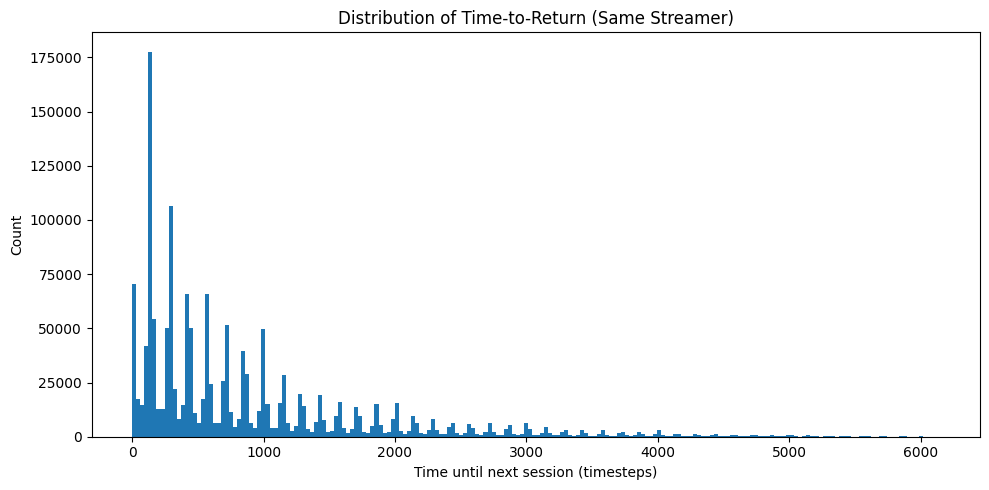

In [7]:
plt.figure(figsize=(10,5))

plt.hist(return_gaps, bins=200)

plt.xlabel("Time until next session (timesteps)")
plt.ylabel("Count")
plt.title("Distribution of Time-to-Return (Same Streamer)")

plt.tight_layout()
plt.savefig(FIG_DIR / "return_time_distribution.png", dpi=200)

plt.show()

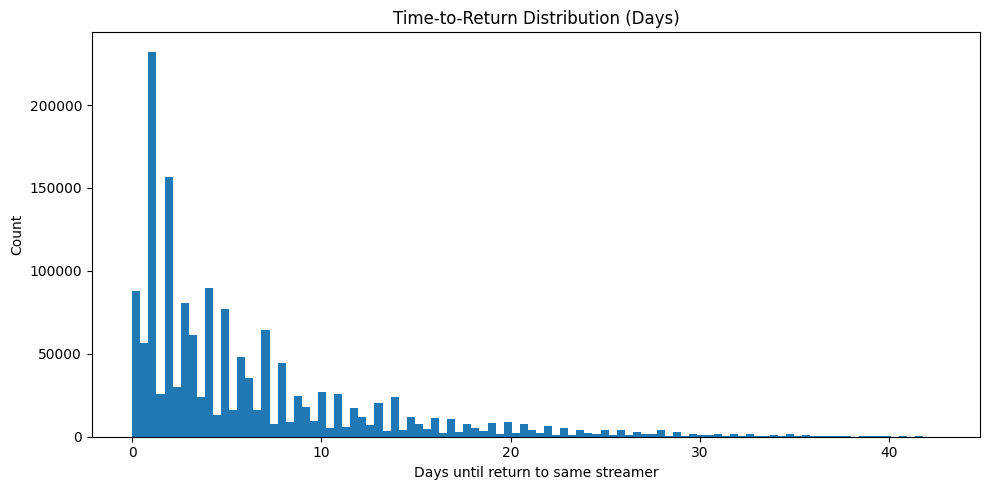

In [8]:
return_days = return_gaps / 144

plt.figure(figsize=(10,5))

plt.hist(return_days, bins=100)

plt.xlabel("Days until return to same streamer")
plt.ylabel("Count")
plt.title("Time-to-Return Distribution (Days)")

plt.tight_layout()
plt.savefig(FIG_DIR / "return_time_days_distribution.png", dpi=200)

plt.show()

### Time-to-Return Distribution

To understand how quickly users return to previously watched streamers, the time difference between consecutive sessions of the same user–streamer pair was computed.

For each `(user_id, streamer_name)` group, sessions were ordered chronologically, and the time gap between consecutive interactions was calculated in timesteps. Since each timestep corresponds to a 10-minute interval, the gaps were also converted to days for easier interpretation.

The resulting distribution reveals a strongly right-skewed pattern. Most returns occur within the first few days after the previous interaction, while a long tail of delayed returns extends over several weeks.

This pattern is consistent with typical user behavior on live streaming platforms, where short-term re-engagement is common, while long-term revisits occur less frequently.

### Interpretation of Return Behavior

The histogram indicates that the majority of return events occur within the first few days after the previous viewing session. The density of observations decreases rapidly as the return time increases, forming a long-tailed distribution.

Small periodic structures are also visible in the histogram, which correspond to the daily activity cycle observed earlier in the temporal activity analysis. Since the dataset is based on 10-minute snapshots, one day corresponds to 144 timesteps, which explains the repeated peaks in the distribution.

Overall, the results suggest that re-engagement on Twitch is predominantly a short-term phenomenon, with most users returning to the same streamer within a relatively short time window.

### Choice of Prediction Horizon

Based on the observed return-time distribution, a prediction horizon of **three days** was selected for defining the re-engagement target.

A very short horizon (e.g., one day) would miss a substantial portion of legitimate return events, while a very long horizon (e.g., one week) would include many delayed interactions that may be less relevant for short-term engagement prediction.

A three-day window provides a balanced compromise: it captures a large share of meaningful return events while maintaining a clear focus on short-term re-engagement behavior.

Formally, the binary target variable is defined as:

$$
y_{u,s,t} =
\begin{cases}
1 & \text{if user } u \text{ returns to streamer } s \text{ within the next 3 days after time } t \\
0 & \text{otherwise}
\end{cases}
$$

Given the 10-minute snapshot resolution of the dataset, a three-day window corresponds to **432 timesteps**.

It is important to note that each (user_id, stream_id) pair appears only once in the dataset. This implies that repeated visits of the same user to the same broadcast cannot be directly observed as separate events.

Instead, the dataset records the span between the first and last observed presence of a user within a stream. As a result, multiple short visits to the same broadcast may be aggregated into a single interaction interval.

However, this limitation does not affect the definition of the re-engagement target used in this study. The prediction task focuses on whether a user returns to the same **streamer**, rather than the same individual broadcast. Since different broadcasts of the same streamer are represented by different `stream_id` values, streamer-level re-engagement events remain observable in the data.

# 4. Positive Rate by Horizon (Class Imbalance Analysis)

In [9]:
# Convert horizons to timesteps
H_1d = 144
H_3d = 432
H_7d = 1008

# Compute positive rates
pos_1d = (return_gaps <= H_1d).mean()
pos_3d = (return_gaps <= H_3d).mean()
pos_7d = (return_gaps <= H_7d).mean()

print("Positive rate (1 day):", round(pos_1d, 3))
print("Positive rate (3 days):", round(pos_3d, 3))
print("Positive rate (7 days):", round(pos_7d, 3))

Positive rate (1 day): 0.169
Positive rate (3 days): 0.435
Positive rate (7 days): 0.705


### Positive Rate Across Candidate Prediction Horizons

To evaluate how the prediction horizon affects the class distribution, the positive rate was computed for several candidate horizons: 1 day, 3 days, and 7 days.

The results show a clear increase in positive labels as the horizon expands. A one-day horizon results in a relatively low positive rate (approximately 17%), which introduces substantial class imbalance. In contrast, a seven-day horizon produces a high positive rate (around 70%), meaning that most samples become positive, which weakens the predictive difficulty of the task.

A three-day horizon provides a balanced compromise, with a positive rate of approximately 43%. This setting captures a large share of meaningful short-term return events while maintaining a reasonably balanced class distribution.

Based on these results, a **3-day prediction horizon** was selected for defining the re-engagement target.

# 5. Interaction Structure (Graph Perspective)

## User Degree

In [10]:
# Number of streams watched by each user
user_degree = df.groupby("user_id")["stream_id"].nunique()

print("Number of users:", len(user_degree))
print("Average streams per user:", round(user_degree.mean(), 2))
print("Median streams per user:", user_degree.median())

Number of users: 100000
Average streams per user: 30.52
Median streams per user: 16.0


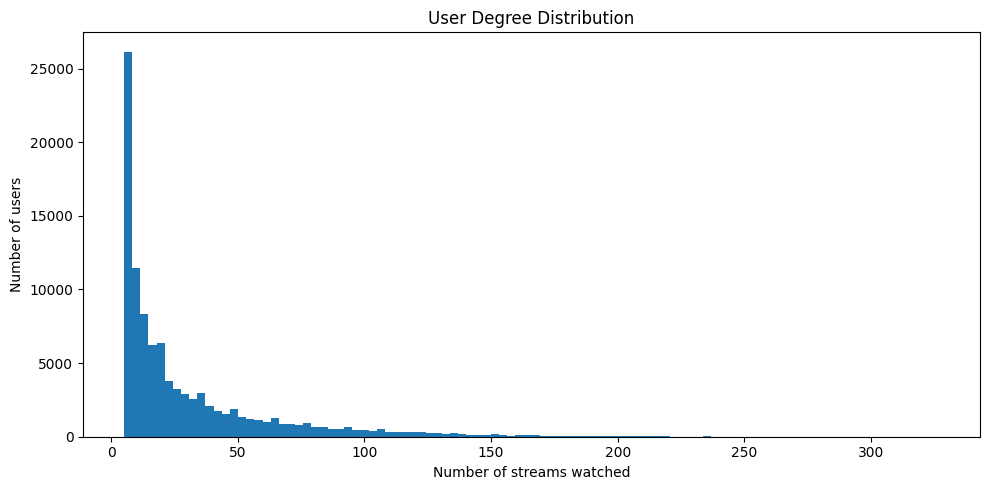

In [11]:
plt.figure(figsize=(10,5))

plt.hist(user_degree, bins=100)

plt.xlabel("Number of streams watched")
plt.ylabel("Number of users")
plt.title("User Degree Distribution")

plt.tight_layout()
plt.savefig(FIG_DIR / "user_degree_distribution.png", dpi=200)

plt.show()

## Stream Degree

In [12]:
# Number of viewers per stream
stream_degree = df.groupby("stream_id")["user_id"].nunique()

print("Number of streams:", len(stream_degree))
print("Average viewers per stream:", round(stream_degree.mean(), 2))
print("Median viewers per stream:", stream_degree.median())

Number of streams: 739991
Average viewers per stream: 4.12
Median viewers per stream: 1.0


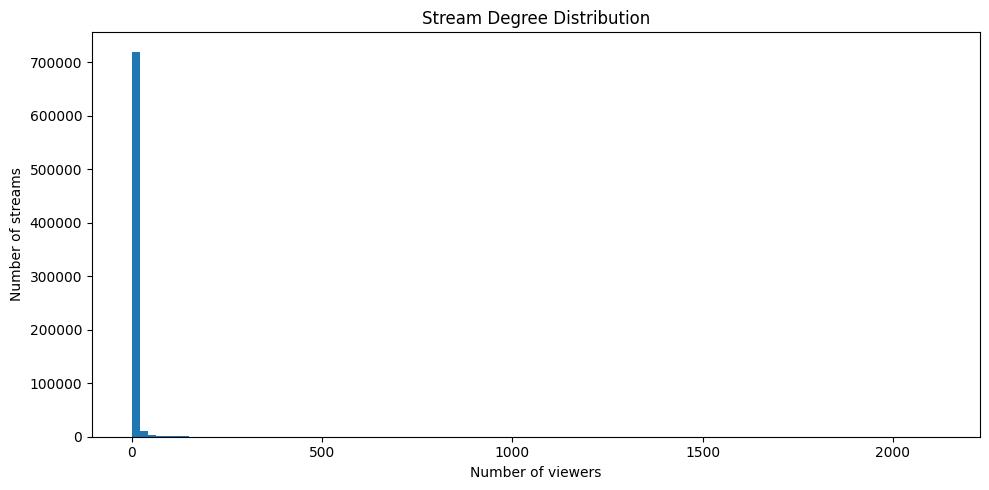

In [13]:
plt.figure(figsize=(10,5))

plt.hist(stream_degree, bins=100)

plt.xlabel("Number of viewers")
plt.ylabel("Number of streams")
plt.title("Stream Degree Distribution")

plt.tight_layout()
plt.savefig(FIG_DIR / "stream_degree_distribution.png", dpi=200)

plt.show()

## Log Scale

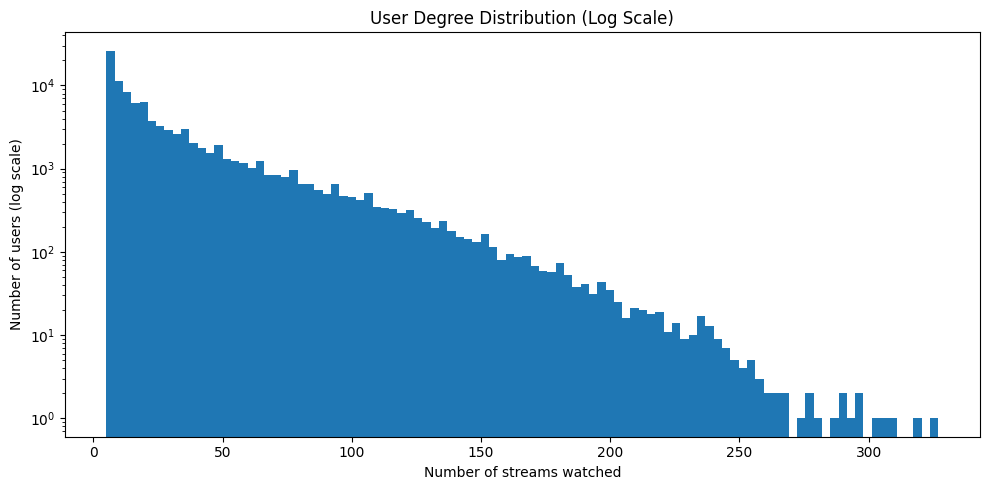

In [14]:
plt.figure(figsize=(10,5))

plt.hist(user_degree, bins=100, log=True)

plt.xlabel("Number of streams watched")
plt.ylabel("Number of users (log scale)")
plt.title("User Degree Distribution (Log Scale)")

plt.tight_layout()
plt.savefig(FIG_DIR / "user_degree_distribution_log.png", dpi=200)

plt.show()

### Interaction Structure of the User–Stream Network

The interaction dataset can be represented as a bipartite graph where users and streams correspond to two distinct node types, and each observed viewing interaction forms an edge between them.

The degree distribution of users indicates that most users interact with a relatively small number of streams, while a smaller subset of highly active users engage with many streams. The median user interacts with 16 distinct streams, while the mean is approximately 30 streams, indicating a right-skewed distribution with a long tail of highly active users.

For streams, the degree distribution shows that many streams are observed with only a single viewer within the sampled dataset. This is reflected in the median viewer count of 1 per stream. This pattern arises from the user-centered sampling procedure used to construct the dataset: the data contains interactions from a fixed set of sampled users rather than all viewers of each stream. As a result, many streams appear with only a single observed viewer even though they may have had additional viewers outside the sampled user set.

Overall, the interaction structure exhibits a sparse and heavy-tailed pattern typical of online content platforms, where many items receive limited attention while a small number of popular items accumulate large audiences.